In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [2]:
df = pd.read_csv("table_group_params.csv")

In [3]:
rproj_fit_mult=df.rproj_fit_mult.to_numpy()
vproj_fit_mult=df.vproj_fit_mult.to_numpy()
vproj_fit_offset=df.vproj_fit_offset.to_numpy()
gdrproj_fit_mult=df.gd_rproj_fit_mult.to_numpy()
gdvproj_fit_mult=df.gd_vproj_fit_mult.to_numpy()
gdvproj_fit_offset=df.gd_vproj_fit_offset.to_numpy()
labels=["({a:d},{b:d},{c:d},{d:d},{e:d},{f:d})".format(a=rproj_fit_mult[ii], b=vproj_fit_mult[ii], c=vproj_fit_offset[ii], d=gdrproj_fit_mult[ii], e=gdvproj_fit_mult[ii], f=gdvproj_fit_offset[ii]) for ii in range(0,len(df))]
labels_for_giant_params=["({a:d}, {b:d}, {c:d})".format(a=rproj_fit_mult[ii], b=vproj_fit_mult[ii], c=vproj_fit_offset[ii]) for ii in range(0,len(df))]
df.loc[:,'labels_giant_params']=labels_for_giant_params

In [4]:
giantresults = df.groupby('labels_giant_params').median()
giantresults=giantresults[(giantresults.rproj_fit_mult>1)&(giantresults.vproj_fit_mult>1)]

In [5]:
giantresults

,rproj_fit_mult,vproj_fit_mult,vproj_fit_offset,gd_rproj_fit_mult,gd_vproj_fit_mult,gd_vproj_fit_offset,mu_HME,mu_HME_dyn,P_G,C_G,...,mu_HME_dw,P_G_dw,C_G_dw,P_H_dw,C_H_dw,P_G_dwgt1,C_G_dwgt1,P_H_dwgt1,C_H_dwgt1,mu_HME_dwgt1
labels_giant_params,,,,,,,,,,,,,,,,,,,,,
"(2, 2, 100)",2.0,2.0,100.0,3.5,3.5,150.0,0.163000,0.221737,0.993128,0.869553,...,0.165000,0.999485,0.877291,0.988016,0.907163,0.982403,0.956852,0.977539,0.960183,0.144000
"(2, 2, 200)",2.0,2.0,200.0,3.5,3.5,150.0,0.161000,0.224871,0.992725,0.876396,...,0.163000,0.999478,0.883504,0.988395,0.911436,0.982096,0.959737,0.979663,0.963127,0.147513
"(2, 2, 300)",2.0,2.0,300.0,3.5,3.5,150.0,0.161000,0.237029,0.992282,0.880100,...,0.163000,0.999474,0.887354,0.988944,0.913324,0.981938,0.958648,0.979502,0.962133,0.148020
"(2, 3, 100)",2.0,3.0,100.0,3.5,3.5,150.0,0.161167,0.237029,0.992837,0.875461,...,0.163505,0.999415,0.883649,0.988913,0.910696,0.980426,0.959347,0.978073,0.962713,0.148000
"(2, 3, 200)",2.0,3.0,200.0,3.5,3.5,150.0,0.161000,0.240184,0.992502,0.880706,...,0.162003,0.999474,0.888468,0.989248,0.913616,0.982174,0.959912,0.979788,0.963417,0.151000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"(6, 5, 200)",6.0,5.0,200.0,3.5,3.5,150.0,0.205000,0.870974,0.956522,0.968439,...,0.209000,0.984387,0.978338,0.979259,0.980961,0.845354,0.986575,0.835886,0.987431,0.275000
"(6, 5, 300)",6.0,5.0,300.0,3.5,3.5,150.0,0.207000,0.909256,0.954512,0.969208,...,0.212000,0.983378,0.979277,0.978355,0.981639,0.839351,0.986789,0.829979,0.987632,0.278623
"(6, 6, 100)",6.0,6.0,100.0,3.5,3.5,150.0,0.204000,0.870211,0.957869,0.966439,...,0.208000,0.984401,0.976470,0.979258,0.979518,0.844768,0.984177,0.836861,0.985933,0.275000


In [6]:
giantmaxs=df.groupby('labels_giant_params').max()
giantmins = df.groupby('labels_giant_params').min()

In [7]:
giantrangedf = giantmaxs-giantmins

In [8]:
giantrangedf

,rproj_fit_mult,vproj_fit_mult,vproj_fit_offset,gd_rproj_fit_mult,gd_vproj_fit_mult,gd_vproj_fit_offset,mu_HME,mu_HME_dyn,P_G,C_G,...,mu_HME_dw,P_G_dw,C_G_dw,P_H_dw,C_H_dw,P_G_dwgt1,C_G_dwgt1,P_H_dwgt1,C_H_dwgt1,mu_HME_dwgt1
labels_giant_params,,,,,,,,,,,,,,,,,,,,,
"(1, 1, 100)",0,0,0,5,5,300,1.000000e-03,0.000000,0.000022,0.003640,...,0.001182,0.000000,0.004544,0.000065,0.004784,0.000000,0.017686,0.000981,0.022674,0.003000
"(1, 1, 200)",0,0,0,5,5,300,1.000000e-03,0.000000,0.000021,0.003393,...,0.001000,0.000000,0.004241,0.000056,0.004419,0.000000,0.021229,0.000734,0.026572,0.007000
"(1, 1, 300)",0,0,0,5,5,300,1.000000e-03,0.000000,0.000017,0.002717,...,0.001000,0.000000,0.003400,0.000041,0.003530,0.000000,0.009703,0.001127,0.015970,0.041684
"(1, 2, 100)",0,0,0,5,5,300,1.000000e-03,0.000000,0.000022,0.003689,...,0.001000,0.000000,0.004615,0.000064,0.004842,0.000000,0.017686,0.000834,0.022966,0.004000
"(1, 2, 200)",0,0,0,5,5,300,1.693090e-15,0.000000,0.000023,0.003728,...,0.001000,0.000000,0.004666,0.000061,0.004892,0.000000,0.018597,0.000819,0.023897,0.012243
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"(6, 5, 200)",0,0,0,5,5,300,7.000000e-03,0.000929,0.004291,0.019671,...,0.007701,0.004611,0.026191,0.004582,0.025466,0.018624,0.026856,0.014075,0.025142,0.004000
"(6, 5, 300)",0,0,0,5,5,300,6.326777e-03,0.030477,0.004281,0.018466,...,0.007000,0.004160,0.024679,0.003912,0.023931,0.019405,0.023761,0.015563,0.022192,0.003000
"(6, 6, 100)",0,0,0,5,5,300,6.829403e-03,0.002340,0.005207,0.022479,...,0.008000,0.005348,0.029880,0.005735,0.029181,0.017272,0.027782,0.009688,0.026725,0.005012


# Lollipop chart for selecting dwarf-association parameters

In [9]:
pg=giantresults.P_G.to_numpy()
cg=giantresults.C_G.to_numpy()
ph=giantresults.P_H.to_numpy()
ch=giantresults.C_H.to_numpy()
mu_phys=giantresults.mu_HME.to_numpy()
mu=giantresults.mu_HME.to_numpy()#/np.median(giantresults.mu_HME.to_numpy())
fn=interp1d([np.max(mu),np.min(mu)],[0.7,1])
mu=fn(mu)
mu_dyn=giantresults.mu_HME_dyn.to_numpy()
mu_dyn_rank = interp1d([np.max(mu_dyn),np.min(mu_dyn)],[0.7,1])(mu_dyn)
#mu=1-rankdata(mu,'max')/len(x)
pgtimescg=pg*cg
phtimesch=ph*ch
pgrange=giantrangedf.P_G.to_numpy()
cgrange=giantrangedf.C_G.to_numpy()
phrange=giantrangedf.P_H.to_numpy()
chrange=giantrangedf.C_H.to_numpy()
mu_physrange=giantrangedf.mu_HME.to_numpy()

order=np.argsort(pgtimescg)
pg=pg[order]
cg=cg[order]
ch=ch[order]
ph=ph[order]
mu=mu[order]
mu_dyn=mu_dyn[order]
mu_dyn_rank=mu_dyn_rank[order]
mu_phys=mu_phys[order]
phtimesch=phtimesch[order]
pgtimescg=pgtimescg[order]
pgrange=pgrange[order]
cgrange=cgrange[order]
phrange=phrange[order]
chrange=chrange[order]
newlabels=np.array(giantresults.index.to_numpy())[order]

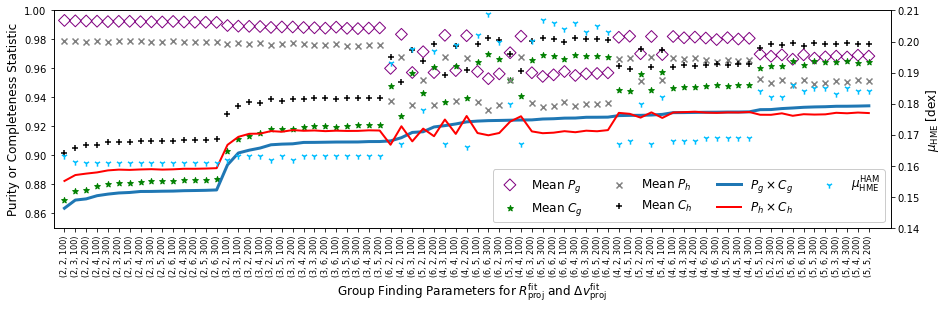

In [10]:
myrange=np.arange(1,len(pg)+1)
fig,ax=plt.subplots(figsize=(15,4))
ax.scatter(myrange-1,pg,edgecolors='purple',facecolors='None',marker='D',label='Mean $P_g$',s=70)
ax.scatter(myrange-1,cg,color='green',marker='*', label='Mean $C_g$')
ax.scatter(myrange-1,ph,color='gray',marker='x', label='Mean $P_h$')
ax.scatter(myrange-1,ch,color='k',marker='+', label='Mean $C_h$',s=30)
ax.plot(myrange-1,pgtimescg,color='tab:blue', linewidth=3,label=r'$P_g \times C_g$')
ax.plot(myrange-1,phtimesch,color='red',linewidth=2, label=r'$P_h \times C_h$')
ax.set_xticks(myrange-1,newlabels, rotation='vertical',fontsize=8)
ax.set_xlabel(r"Group Finding Parameters for $R_{\rm proj}^{\rm fit}$ and $\Delta v_{\rm proj}^{\rm fit}$",fontsize=12)
ax.set_ylim(0.85,1.0)
ax.set_xlim(-1,max(myrange)+1)
ax.set_ylabel("Purity or Completeness Statistic",fontsize=12)
ax1=ax.twinx()
ax1.scatter(myrange-1,mu_phys,marker='1',color='deepskyblue',s=40,label=r'$\mu_{\rm HME}^{\rm HAM}$')
ax1.scatter(myrange-1,mu_dyn,marker='2',color='olive')
ax.scatter(-99,-99,marker='1',color='deepskyblue',s=40,label=r'$\mu_{\rm HME}^{\rm HAM}$')
ax1.set_ylabel(r'$\mu_{\rm HME}$ [dex]',fontsize=12)
ax1.set_ylim(0.14,0.21)

ax.legend(loc='lower right', framealpha=1, fontsize=12, ncol=4)
plt.show()

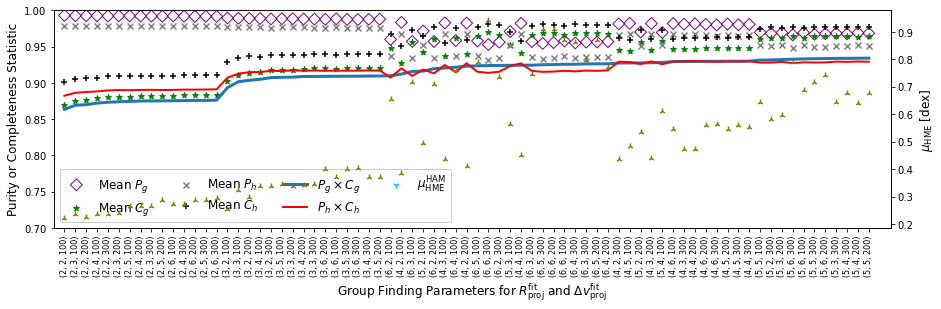

In [11]:
myrange=np.arange(1,len(pg)+1)
fig,ax=plt.subplots(figsize=(15,4))
ax.scatter(myrange-1,pg,edgecolors='purple',facecolors='None',marker='D',label='Mean $P_g$',s=70)
ax.scatter(myrange-1,cg,color='green',marker='*', label='Mean $C_g$')
ax.scatter(myrange-1,ph,color='gray',marker='x', label='Mean $P_h$')
ax.scatter(myrange-1,ch,color='k',marker='+', label='Mean $C_h$',s=30)
ax.plot(myrange-1,pgtimescg,color='tab:blue', linewidth=3,label=r'$P_g \times C_g$')
ax.plot(myrange-1,phtimesch,color='red',linewidth=2, label=r'$P_h \times C_h$')
ax.set_xticks(myrange-1,newlabels, rotation='vertical',fontsize=8)
ax.set_xlabel(r"Group Finding Parameters for $R_{\rm proj}^{\rm fit}$ and $\Delta v_{\rm proj}^{\rm fit}$",fontsize=12)
ax.set_ylim(0.7,1.0)
ax.set_xlim(-1,max(myrange)+1)
ax.set_ylabel("Purity or Completeness Statistic",fontsize=12)
ax1=ax.twinx()
#ax1.scatter(myrange-1,mu_phys,marker='1',color='deepskyblue',s=40,label=r'$\mu_{\rm HME}^{\rm HAM}$')
ax1.scatter(myrange-1,mu_dyn,marker='2',color='olive')
ax.scatter(-99,-99,marker='1',color='deepskyblue',s=40,label=r'$\mu_{\rm HME}^{\rm HAM}$')
ax1.set_ylabel(r'$\mu_{\rm HME}$ [dex]',fontsize=12)
#ax1.set_ylim(0.15,0.18)

ax.legend(loc='lower left', framealpha=1, fontsize=12, ncol=4)
plt.show()

In [ ]:
myrange=np.arange(1,len(pg)+1)
fig,ax=plt.subplots(figsize=(15,4))
ax.scatter(myrange-1,pg,edgecolors='purple',facecolors='None',marker='D',label='Mean $P_g$',s=70)
ax.scatter(myrange-1,cg,color='green',marker='*', label='Mean $C_g$')
ax.scatter(myrange-1,ph,color='gray',marker='x', label='Mean $P_h$')
ax.scatter(myrange-1,ch,color='k',marker='+', label='Mean $C_h$',s=30)
ax.plot(myrange-1,pgtimescg,color='tab:blue', linewidth=3,label=r'$P_g \times C_g$')
ax.plot(myrange-1,phtimesch,color='red',linewidth=2, label=r'$P_h \times C_h$')
ax.set_xticks(myrange-1,newlabels, rotation='vertical',fontsize=8)
ax.set_xlabel(r"Group Finding Parameters for $R_{\rm proj}^{\rm fit}$ and $\Delta v_{\rm proj}^{\rm fit}$",fontsize=12)
ax.set_ylim(0.7,1.0)
ax.set_xlim(-1,max(myrange)+1)
ax.set_ylabel("Purity or Completeness Statistic",fontsize=12)
#ax1=ax.twinx()
ax.scatter(myrange-1,mu,marker='1',color='deepskyblue',s=40,label=r'$\mu_{\rm HME}^{\rm HAM}$')
ax.scatter(myrange-1,mu_dyn_rank,marker='2',color='olive',s=60, label=r'$\mu_{\rm HME}^{\rm dyn}$')
#ax.scatter(-99,-99,marker='1',color='deepskyblue',s=40,label=r'$\mu_{\rm HME}^{\rm HAM}$')
#ax1.set_ylabel(r'$\mu_{\rm HME}$ [dex]',fontsize=12)
ax.set_ylim(0.68,1.02)
ax.legend(loc='lower right', framealpha=1, fontsize=12, ncol=4)
plt.show()

# Dwarf-Only Optimization